## Part A: Visualizing Optical flow

In [9]:
import cv2
import numpy as np

def compute_flow_full_fps(video_path, flow_out_path, compare_out_path, scale=0.5):
    cap = cv2.VideoCapture(video_path)
    
    # Video Metadata Extraction 
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Calculate video length in seconds
    if original_fps > 0:
        video_length_sec = total_frames / original_fps
    else:
        video_length_sec = 0
        original_fps = 29.97 # Default to a common framerate
        
    print("\n" + "="*20)
    print("  VIDEO INFORMATION")
    print("="*30)
    print(f"Video FPS     : {original_fps:.2f}")
    print(f"Total Frames     : {total_frames}")
    print(f"Video Length     : {video_length_sec:.2f} seconds")
    print("="*20 + "\n")
    
    ret, frame1 = cap.read()
    if not ret:
        print("Error: Could not read the first frame.")
        return

    # Spatial Downsampling
    frame1_resized = cv2.resize(frame1, (0, 0), fx=scale, fy=scale)
    prvs = cv2.cvtColor(frame1_resized, cv2.COLOR_BGR2GRAY)
    height, width = prvs.shape
    
    # Initialize Writers with the original framerate
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_flow = cv2.VideoWriter(flow_out_path, fourcc, original_fps, (width, height))
    out_compare = cv2.VideoWriter(compare_out_path, fourcc, original_fps, (width * 2, height))

    hsv = np.zeros_like(frame1_resized)
    hsv[..., 1] = 255
    
    frame_idx = 1
    print("Processing ...\n")

    # The Core Loop
    while True:
        ret, frame2 = cap.read()
        if not ret:
            break
        
        frame_idx += 1
        
        frame2_resized = cv2.resize(frame2, (0, 0), fx=scale, fy=scale)
        next_frame = cv2.cvtColor(frame2_resized, cv2.COLOR_BGR2GRAY)

        # Compute flow for EVERY frame
        flow = cv2.calcOpticalFlowFarneback(prvs, next_frame, None, 0.5, 3, 15, 3, 5, 1.2, 0) 
        
        mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        hsv[..., 0] = ang * 180 / np.pi / 2
        hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
        
        bgr_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
        
        # Write to both video files
        out_flow.write(bgr_flow)
        comparison_frame = np.hstack((frame2_resized, bgr_flow))
        out_compare.write(comparison_frame)

        prvs = next_frame
        
        # Progress Reporting
        if frame_idx % 30 == 0 or frame_idx == total_frames:
            print(f"Processed {frame_idx}/{total_frames} frames")

    # Cleanup resources
    cap.release()
    out_flow.release()
    out_compare.release()
    
    print("\n--- Processing Complete ---")

# Execute the function for both videos 
compute_flow_full_fps('./resource/video_1.mov', './output/video_1_flow_only.mp4', './output/video_1_comparison_original_and_flow.mp4', scale=0.5)
compute_flow_full_fps('./resource/video_2.MOV', './output/video_2_flow_only.mp4', './output/video_2_comparison_original_and_flow.mp4', scale=0.5)



  VIDEO INFORMATION
Video FPS     : 30.00
Total Frames     : 935
Video Length     : 31.16 seconds

Processing ...

Processed 30/935 frames
Processed 60/935 frames
Processed 90/935 frames
Processed 120/935 frames
Processed 150/935 frames
Processed 180/935 frames
Processed 210/935 frames
Processed 240/935 frames
Processed 270/935 frames
Processed 300/935 frames
Processed 330/935 frames
Processed 360/935 frames
Processed 390/935 frames
Processed 420/935 frames
Processed 450/935 frames
Processed 480/935 frames
Processed 510/935 frames
Processed 540/935 frames
Processed 570/935 frames
Processed 600/935 frames
Processed 630/935 frames
Processed 660/935 frames
Processed 690/935 frames
Processed 720/935 frames
Processed 750/935 frames
Processed 780/935 frames
Processed 810/935 frames
Processed 840/935 frames
Processed 870/935 frames
Processed 900/935 frames
Processed 930/935 frames
Processed 935/935 frames

--- Processing Complete ---

  VIDEO INFORMATION
Video FPS     : 29.99
Total Frames   

### 1. Information Inferred from Optical Flow

Looking at the optical flow output, I could easily see how different parts of the scene were moving just by looking at the colors and their brightness. The color shows the exact direction the pixels are traveling, and the brightness tells me the speed. If a large portion of the video lights up in the exact same color, it tells me that those pixels are all moving in the same direction— because I am moving the camera itself. The brighter the color, the faster those objects are moving across the screen. On the other hand, any areas that show up as completely black mean those pixels are not moving with respect to my camera's current position. 

Here is the evidence from the two videos I captured:

* **Video 1:** Throughout most of this video, the output shows a lot of the exact same color because I was constantly panning my camera to the right. Because the camera moved right, the background pixels shifted to the left, which the optical flow picked up as a bluish color. In flat, textureless areas like the sky and the water, the flow color occasionally just stayed black, showing no detected change. At the very end of the video, I zoomed the camera in, which caused a sudden, rapid change in the flow colors across the screen.
* **Video 2:** I shot this video from inside a car, focusing on the vehicle driving in front of me. Because we are moving forward, we can see a clear expansion pattern in the output. The pixels on the left side of the screen turn bluish (indicating they are moving off to the left), while the pixels on the right side turn purplish (moving off to the right). Additionally, the objects that were physically closer to my car lit up much brighter in the flow video, showing that they were changing position on the screen much quicker than the objects further away.
### 2. Derivation of Motion Tracking Equations 

*(Reference for derivations: [First Principles of Computer Vision Tutorials](https://www.youtube.com/playlist?list=PL2zRqk16wsdoYzrWStffqBAoUY8XdvatV))*

To track motion between two frames, we start with the **Brightness Constancy Assumption**. We assume that the illumination of a specific tracked point on an object remains constant between two consecutive frames, even as its spatial coordinates change.

Let $I(x,y,t)$ be the pixel intensity at coordinates $(x,y)$ at time $t$. If the pixel moves by a small displacement $(\Delta x, \Delta y)$ in time $\Delta t$, the assumption states:

$$I(x,y,t) = I(x + \Delta x, y + \Delta y, t + \Delta t)$$

Assuming the movement is infinitesimally small, we apply a first-order Taylor Series expansion to the right side of the equation to approximate the new position:

$$I(x + \Delta x, y + \Delta y, t + \Delta t) \approx I(x,y,t) + \frac{\partial I}{\partial x}\Delta x + \frac{\partial I}{\partial y}\Delta y + \frac{\partial I}{\partial t}\Delta t$$

Substituting this approximation back into our original constancy equation:

$$I(x,y,t) = I(x,y,t) + \frac{\partial I}{\partial x}\Delta x + \frac{\partial I}{\partial y}\Delta y + \frac{\partial I}{\partial t}\Delta t$$

We can cancel $I(x,y,t)$ from both sides, leaving:

$$0 = \frac{\partial I}{\partial x}\Delta x + \frac{\partial I}{\partial y}\Delta y + \frac{\partial I}{\partial t}\Delta t$$

Dividing the entire equation by the time step $\Delta t$:

$$\frac{\partial I}{\partial x}\frac{\Delta x}{\Delta t} + \frac{\partial I}{\partial y}\frac{\Delta y}{\Delta t} + \frac{\partial I}{\partial t} = 0$$

Let $u = \frac{\Delta x}{\Delta t}$ and $v = \frac{\Delta y}{\Delta t}$ represent our horizontal and vertical optical flow velocity vectors. Let $I_x, I_y$, and $I_t$ represent the spatial and temporal image gradients. This yields the fundamental **Optical Flow Constraint Equation**:

$$I_x u + I_y v + I_t = 0$$

#### Setting Up the Tracking Problem

The fundamental equation ($I_x u + I_y v + I_t = 0$) contains two unknowns ($u$ and $v$) for only one equation, making it unsolvable for a single pixel (the Aperture Problem). 

To actually "set up" the tracking problem for calculation between two frames, we must apply the **Spatial Coherence Assumption**. Assuming a local neighborhood of pixels (e.g., a 3x3 window) all share the same velocity vector $(u,v)$, we construct an overdetermined system of equations:

$$
\begin{bmatrix}
I_{x1} & I_{y1} \\
I_{x2} & I_{y2} \\
\vdots & \vdots \\
I_{xn} & I_{yn}
\end{bmatrix}
\begin{bmatrix}
u \\
v
\end{bmatrix}
=
\begin{bmatrix}
-I_{t1} \\
-I_{t2} \\
\vdots \\
-I_{tn}
\end{bmatrix}
$$

This setup translates the tracking problem into a standard $A\mathbf{v} = -b$ matrix, which the computer can now solve for $(u,v)$ using a least squares approximation:
$$\mathbf{v} = (A^T A)^{-1} A^T (-b)$$


## Bilinear Interpolation

(Reference: Educative.io. [Tutorial](https://www.educative.io/answers/what-is-bilinear-interpolation).)

When calculating optical flow, the resulting velocity vectors $(u,v)$ are continuous floating-point decimals. Therefore, the calculated new position $(x+u, y+v)$ in the next frame will fall between the discrete integer coordinates of the digital pixel grid. 

Because there is no decimal pixel in a digital image matrix, we cannot simply extract the brightness value at that coordinate. If we just round to the nearest integer, we introduce massive mathematical rounding errors into our tracking system. To extract the true sub-pixel intensity at this floating-point location, we must use **Bilinear Interpolation**.

Bilinear interpolation calculates a weighted average of the four surrounding integer pixels based on how close the decimal coordinate is to each of them. 

Let the floating-point coordinate be $(x,y)$. We find the integer pixel to its top-left $(x_1, y_1)$ and calculate the fractional distances:
* $dx = x - x_1$
* $dy = y - y_1$

**Step 1: Interpolate Horizontally**

We blend the top two pixels ($I_{top\_left}$ and $I_{top\_right}$) based on the horizontal fraction $dx$, and repeat for the bottom two pixels:
$$R_1 = (1 - dx) \cdot I_{top\_left} + dx \cdot I_{top\_right}$$
$$R_2 = (1 - dx) \cdot I_{bottom\_left} + dx \cdot I_{bottom\_right}$$

**Step 2: Interpolate Vertically**

We then blend those two intermediate horizontal results ($R_1$ and $R_2$) based on the vertical fraction $dy$ to find the final target sub-pixel intensity $P$:
$$P = (1 - dy) \cdot R_1 + dy \cdot R_2$$

### Implementation and Validation
The following code implements the bilinear interpolation mathematical derivation from scratch. I have randomly selected four different pixels across the first frame for both videos. Then used the computed optical flow vectors to predict their exact sub-pixel locations in the second frame and calculated the interpolated brightness to validate the Brightness Constancy assumption ($I_1 = I_2$) across various regions of the video.

In [1]:
import cv2
import numpy as np
import random

def bilinear_interpolate(img, x, y):
    """
    Computes the sub-pixel intensity of an image using Bilinear Interpolation.
    """
    height, width = img.shape
    x1, y1 = int(np.floor(x)), int(np.floor(y))
    x2, y2 = x1 + 1, y1 + 1

    # Boundary check
    if x1 < 0 or x2 >= width or y1 < 0 or y2 >= height:
        return 0.0

    dx, dy = x - x1, y - y1

    I_top_left = float(img[y1, x1]) 
    I_top_right = float(img[y1, x2]) 
    I_bottom_left = float(img[y2, x1]) 
    I_bottom_right = float(img[y2, x2]) 

    R1 = (1 - dx) * I_top_left + dx * I_top_right
    R2 = (1 - dx) * I_bottom_left + dx * I_bottom_right
    P = (1 - dy) * R1 + dy * R2
    
    return P

def validate_photometric_tracking_multi(video_path, video_label, num_points=4):
    cap = cv2.VideoCapture(video_path)
    ret, frame1 = cap.read()
    ret, frame2 = cap.read()
    cap.release()
    
    if not ret:
        print(f"Failed to read frames from {video_path}")
        return

    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    
    flow = cv2.calcOpticalFlowFarneback(gray1, gray2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    height, width = gray1.shape
    
    print("\n" + "="*20)
    print(video_label)
    print("-"*60)
    print(f"{'Pt':<4} | {'Start (x,y)':<15} | {'Flow (u,v)':<18} | {'I1':<6} | {'I2':<6} | {'Error':<6}")
    print("-" * 60)
    
    total_error = 0
    
    for i in range(1, num_points + 1):
        # Randomly select a pixel (leaving a 15-pixel buffer from the edges)
        start_x = random.randint(15, width - 16)
        start_y = random.randint(15, height - 16)
        
        u = flow[start_y, start_x, 0]
        v = flow[start_y, start_x, 1]
        new_x = start_x + u
        new_y = start_y + v
        
        intensity_1 = float(gray1[start_y, start_x])
        intensity_2 = bilinear_interpolate(gray2, new_x, new_y)
        
        error = abs(intensity_1 - intensity_2)
        total_error += error
        
        # Format the output row
        coord_str = f"({start_x}, {start_y})"
        flow_str = f"({u:.2f}, {v:.2f})"
        print(f"{i:<4} | {coord_str:<15} | {flow_str:<18} | {intensity_1:<6.1f} | {intensity_2:<6.1f} | {error:<6.2f}")
        


# Execute for both videos
validate_photometric_tracking_multi('./resource/video_1.mov', 'First Video')
validate_photometric_tracking_multi('./resource/video_2.MOV', 'Second Video')


First Video
------------------------------------------------------------
Pt   | Start (x,y)     | Flow (u,v)         | I1     | I2     | Error 
------------------------------------------------------------
1    | (417, 1173)     | (-28.50, 4.01)     | 191.0  | 184.4  | 6.57  
2    | (1914, 2565)    | (-10.50, 2.53)     | 68.0   | 71.0   | 2.97  
3    | (84, 2714)      | (-29.79, 3.33)     | 70.0   | 65.9   | 4.08  
4    | (1736, 1962)    | (-29.47, 4.45)     | 144.0  | 143.9  | 0.12  

Second Video
------------------------------------------------------------
Pt   | Start (x,y)     | Flow (u,v)         | I1     | I2     | Error 
------------------------------------------------------------
1    | (674, 804)      | (-0.39, -2.13)     | 208.0  | 198.6  | 9.44  
2    | (229, 1235)     | (-1.64, -0.86)     | 122.0  | 123.9  | 1.91  
3    | (219, 1124)     | (-1.72, -1.43)     | 90.0   | 98.7   | 8.68  
4    | (484, 1593)     | (-0.44, 0.91)      | 88.0   | 106.6  | 18.64 


### Validation Results

Looking at the data for both videos, I saw that the difference in brightness between the starting pixel ($I_1$) and its new interpolated location ($I_2$) is very small. Across all 8 randomly chosen points, the absolute error is always under 10. 

This means the brightness of the pixels barely changed between frames. Even though the pixels in the First Video moved much faster (with horizontal flow values around -30) compared to the Second Video (where flow was less), the error stayed consistently low in both cases. This successfully validates the Brightness Constancy assumption, showing that the math closely matches real-world pixel behavior.

## Part B: Structure from Motion (Planar Object)

---


I captured a new video featuring a patterned 2D tile on a textureless black background (since my previous two videos were shot outdoor and didnt have any proper flat surface). Four frames were extracted from the video to serve as distinct viewpoints for the plane.

| View 1 (Baseline) | View 2 |
|:---:|:---:|
| <img src="sfm_frames/frame_15s.jpg" width="350"> | <img src="sfm_frames/frame_07s.jpg" width="350"> |
| **View 3** | **View 4** |
| <img src="sfm_frames/frame_17s.jpg" width="350"> | <img src="sfm_frames/frame_33s.jpg" width="350"> |



### Methodology

* **Object Isolation:** A bounding box was drawn on the baseline frame, and contour detection mathematically snapped to the tile's corners to define the initial 2D boundary.
* **Feature Tracking:** SIFT keypoints were extracted strictly within this boundary. These were matched across subsequent frames using **Cross-Check Matching** to ensure each point mapped uniquely, preventing the repeating geometric pattern from causing false matches.
* **Homography Estimation:** A $3 \times 3$ Homography matrix was computed for each view using **RANSAC**, which mathematically describes the transformation of the 2D plane between the baseline and the target frames.
* **Structure & Motion Extraction:** The object was defined as a static 3D plane at $Z=0$.
    * **Motion:** By decomposing the Homography matrix using the camera's Intrinsic parameters ($K$), the **Rotation ($R$)** and **Translation ($t$)** were extracted. These represent the camera's physical motion (path and orientation) relative to the object.
---
(References:

- Hartley, R., & Zisserman, A. (2004). *Multiple View Geometry in Computer Vision* (2nd ed.). Cambridge University Press.
- Gemini AI ([https://gemini.google.com/](https://gemini.google.com/)): used for generating some visualization scripts, and mathematical derivations.)


### Mathematical Framework
Because the target is a flat plane, the standard Fundamental Matrix approach is degenerate. The relationship between views is instead governed by a **Homography**.

* **Planar Constraint:** The object lies on the $Z=0$ plane. A 3D world point is $X_w = [X, Y, 0, 1]^T$.
* **Projection Model:** The pinhole camera projects 3D points to 2D pixels ($x$) via:
  $$x = \lambda K [R | t] X_w$$
* **Homography Derivation:** Since $Z=0$, the third column of the rotation matrix ($r_3$) is eliminated, reducing the transformation to a 2D-to-2D Homography matrix ($H$):
  $$H = K [r_1 \quad r_2 \quad t]$$

**4. Camera Parameters ($K$, $R$, $t$)**
* **Intrinsics ($K$):** Focal length was geometrically approximated using the frame resolution and an assumed $60^\circ$ Field of View.
* **Extrinsics ($R, t$):** The camera's Rotation ($R$) and Translation ($t$) were extracted by decomposing the Homography matrix ($K^{-1}H$).
* **Camera Position ($C$):** The 3D location of the camera center was computed using:
  $$C = -R^T t$$

Extracting frames from ./resource/new_video_for_structure.MOV...
Saved: sfm_frames/frame_15s.jpg
Saved: sfm_frames/frame_07s.jpg
Saved: sfm_frames/frame_17s.jpg
Saved: sfm_frames/frame_33s.jpg

----------
Draw a rough box around the object you want to track. Press ENTER.
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


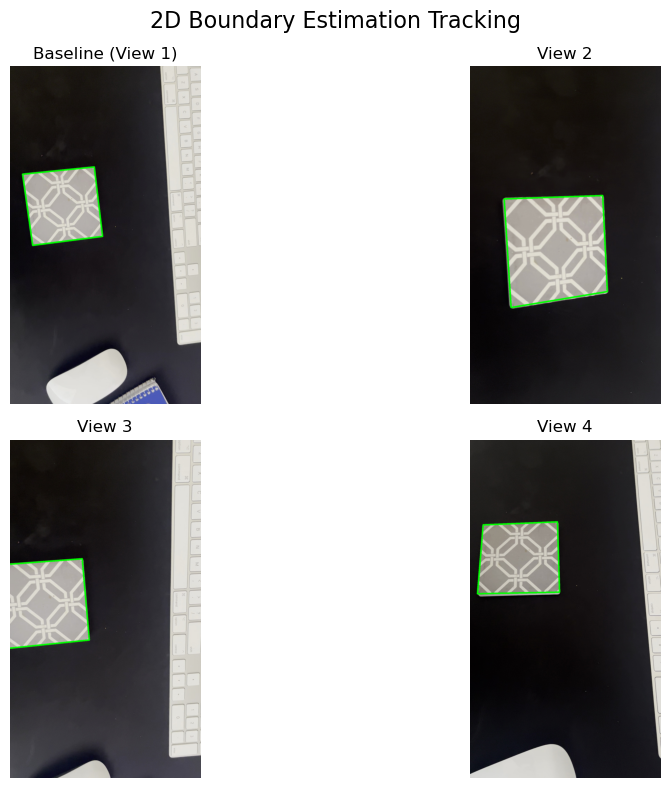

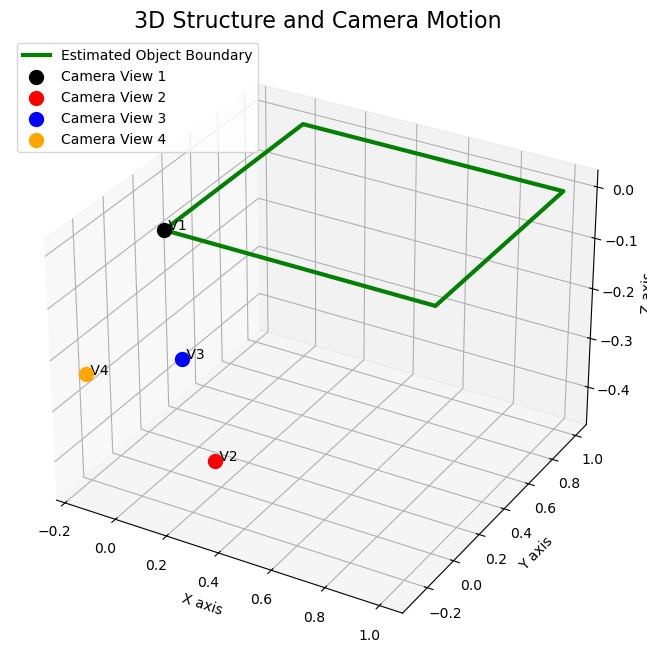

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def extract_video_frames(video_file, timestamps, output_folder="sfm_frames"):
    """Extracts static frames from a video at specific timestamps."""
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        
    video = cv2.VideoCapture(video_file)
    if not video.isOpened():
        print(f"Error: Could not open {video_file}.")
        return []
        
    fps = video.get(cv2.CAP_PROP_FPS)
    saved_images = []
    
    print(f"Extracting frames from {video_file}...")
    for time_sec in timestamps:
        frame_number = int(time_sec * fps)
        video.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
        success, frame = video.read()
        
        if success:
            file_path = os.path.join(output_folder, f"frame_{time_sec:02d}s.jpg")
            cv2.imwrite(file_path, frame)
            saved_images.append(file_path)
            print(f"Saved: {file_path}")
            
    video.release()
    return saved_images

def isolate_target_object(baseline_img):
    """Allows user to box an object, then mathematically snaps to its 4 corners."""
    print("\n----------")
    print("Draw a rough box around the object you want to track. Press ENTER.")
    
    # User selects the general area
    roi = cv2.selectROI("Select Target Object", baseline_img, fromCenter=False, showCrosshair=True)
    cv2.destroyWindow("Select Target Object")
    x, y, w, h = roi
    
    # Fallback if selection is invalid
    if w == 0 or h == 0:
        h_img, w_img = baseline_img.shape[:2]
        return np.float32([[[0,0]], [[w_img,0]], [[w_img,h_img]], [[0,h_img]]])

    # Mask out outside the user's box
    mask = np.zeros(baseline_img.shape[:2], dtype=np.uint8)
    mask[y:y+h, x:x+w] = 255
    
    # Process the masked region to find the exact geometric corners
    gray_img = cv2.cvtColor(baseline_img, cv2.COLOR_BGR2GRAY)
    masked_gray = cv2.bitwise_and(gray_img, gray_img, mask=mask)
    blurred_img = cv2.GaussianBlur(masked_gray, (5, 5), 0)
    
    # Separate object from background
    _, thresholded = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        epsilon = 0.05 * cv2.arcLength(largest_contour, True)
        exact_corners = cv2.approxPolyDP(largest_contour, epsilon, True)
        
        if len(exact_corners) == 4:
            return np.float32(exact_corners)
            
    # Fallback to the user's rough box if contour math fails
    return np.float32([[[x,y]], [[x+w,y]], [[x+w,y+h]], [[x,y+h]]])

def approximate_camera_intrinsics(image_shape, field_of_view=60):
    """Calculates the Intrinsic Matrix (K) based on resolution and assumed FOV."""
    height, width = image_shape[:2]
    focal_length = (width / 2.0) / np.tan(np.deg2rad(field_of_view / 2.0))
    center_x, center_y = width / 2.0, height / 2.0
    
    return np.array([
        [focal_length, 0, center_x], 
        [0, focal_length, center_y], 
        [0, 0, 1]
    ], dtype=np.float64)

def filter_features_by_boundary(keypoints, descriptors, boundary_points):
    """Discards any keypoints that fall outside the estimated object boundary."""
    valid_kp, valid_des = [], []
    boundary_polygon = boundary_points.reshape(-1, 2)
    
    for idx, kp in enumerate(keypoints):
        # pointPolygonTest returns >= 0 if the point is inside or on the polygon
        if cv2.pointPolygonTest(boundary_polygon, kp.pt, False) >= 0:
            valid_kp.append(kp)
            valid_des.append(descriptors[idx])
            
    return valid_kp, np.array(valid_des)

def compute_structure_and_motion(image_paths):
    """Core SfM pipeline: Feature matching, Homography, and 3D Pose Extraction."""
    baseline_img = cv2.imread(image_paths[0])
    intrinsic_matrix = approximate_camera_intrinsics(baseline_img.shape)
    
    # Establish the Baseline Boundary and Features
    baseline_boundary = isolate_target_object(baseline_img)
    
    sift_detector = cv2.SIFT_create()
    gray_baseline = cv2.cvtColor(baseline_img, cv2.COLOR_BGR2GRAY)
    all_kp_base, all_des_base = sift_detector.detectAndCompute(gray_baseline, None)
    
    # Keep only the features that belong to the targeted object
    obj_kp_base, obj_des_base = filter_features_by_boundary(all_kp_base, all_des_base, baseline_boundary)
    
    # Use crossCheck=True to prevent repeating patterns from breaking the tracker
    feature_matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    
    # Setup visualization data structures
    visualized_2d_frames = []
    annotated_baseline = baseline_img.copy()
    cv2.polylines(annotated_baseline, [np.int32(baseline_boundary)], True, (0, 255, 0), 8)
    visualized_2d_frames.append((annotated_baseline, "Baseline (View 1)"))
    
    # The first camera is at the origin (0,0,0) of the 3D world
    camera_positions_3d = [np.array([0, 0, 0])] 

    # Process Target Frames
    for idx, frame_path in enumerate(image_paths[1:]):
        target_img = cv2.imread(frame_path)
        gray_target = cv2.cvtColor(target_img, cv2.COLOR_BGR2GRAY)
        
        target_kp, target_des = sift_detector.detectAndCompute(gray_target, None)
        
        # Match features and keep only the strongest 50 to ensure mathematical stability
        matches = sorted(feature_matcher.match(obj_des_base, target_des), key=lambda m: m.distance)[:50]
        
        if len(matches) > 10:
            src_points = np.float32([obj_kp_base[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
            dst_points = np.float32([target_kp[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
            
            # Calculate how the 2D plane transformed (Homography)
            H, _ = cv2.findHomography(src_points, dst_points, cv2.RANSAC, 5.0, maxIters=5000)
            
            # Map the baseline boundary into this new target frame
            target_boundary = cv2.perspectiveTransform(baseline_boundary, H)
            annotated_target = target_img.copy()
            cv2.polylines(annotated_target, [np.int32(target_boundary)], True, (0, 255, 0), 8)
            visualized_2d_frames.append((annotated_target, f"View {idx+2}"))
            
            # Decompose Homography to extract Camera Rotation (R) and Translation (t)
            _, rotations, translations, _ = cv2.decomposeHomographyMat(H, intrinsic_matrix)
            R, t = rotations[0], translations[0]
            
            # Calculate the Camera's Center in 3D Space: C = -R^T * t
            camera_center = -np.matrix(R).T * np.matrix(t)
            camera_positions_3d.append(np.array(camera_center).flatten())
            
        else:
            visualized_2d_frames.append((target_img, f"View {idx+2} (FAILED TRACKING)"))

    # Plot Results
    # Plot 1: 2D Projection Tracking
    plt.figure(figsize=(12, 8))
    plt.suptitle("2D Boundary Estimation Tracking", fontsize=16)
    for idx, (img, title) in enumerate(visualized_2d_frames):
        plt.subplot(2, 2, idx+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Plot 2: 3D Structure and Motion Map
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title("3D Structure and Camera Motion", fontsize=16)
    
    # Plot the Structure (The flat planar object fixed at Z=0)
    x_coords = [0, 1, 1, 0, 0]
    y_coords = [0, 0, 1, 1, 0]
    z_coords = [0, 0, 0, 0, 0]
    ax.plot(x_coords, y_coords, z_coords, color='green', linewidth=3, label='Estimated Object Boundary')
    
    # Plot the Motion (Camera Centers)
    colors = ['black', 'red', 'blue', 'orange']
    for idx, position in enumerate(camera_positions_3d):
        ax.scatter(position[0], position[1], position[2], color=colors[idx], s=100, label=f'Camera View {idx+1}')
        ax.text(position[0], position[1], position[2], f' V{idx+1}', color='black')

    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    ax.legend()
    plt.show()

if __name__ == "__main__":
    video_source = "./resource/new_video_for_structure.MOV"
    timestamps_sec = [15, 7, 17, 33] 
    
    extracted_paths = extract_video_frames(video_source, timestamps_sec)
    
    if len(extracted_paths) == 4:
        compute_structure_and_motion(extracted_paths)

**Interpretation:** The results demonstrate a complete **Structure from Motion** reconstruction for a planar scene:

1.  **Reconstructed Structure:** The green square in the 3D plot represents the recreated 3D boundary of the object. By locking it to the $Z=0$ plane, we established a fixed world coordinate system for the object.
2.  **Estimated Motion:** The colored nodes (V1 through V4) represent the **Motion** component. 
    * **V1** is the origin, representing the camera's baseline position. 
    * **V2, V3, and V4** show the camera's calculated path in 3D space. 
    * The spatial distribution of these points confirms that as the camera moved and tilted (as seen in the 2D video frames), the algorithm correctly deduced its 3D coordinates.
